# مشروع هندسة وتحليل بيانات المبيعات (Sales Data Engineering & Analytics)

يهدف هذا الدفتر إلى معالجة وتنظيف بيانات المبيعات غير المتناسقة المجمعة من مستودعات ومخازن متعددة، وتوحيد أسماء الصيدليات والمنتجات ومناديب المبيعات، ثم نمذجتها وتحليلها واستخدام التعلم الآلي للتنبؤ واكتشاف العمليات الشاذة.

## المرحلة 1: إعداد البيئة واستكشاف البيانات (Data Exploration & Setup)
في هذه المرحلة سنقوم بـ:
1. استيراد المكتبات الأساسية.
2. تحميل ملف البيانات `supplier_sales_2026-06-04_222403.csv`.
3. استكشاف الأعمدة ونسبة القيم المفقودة (Nulls).
4. استكشاف التكرار والتناقض في المسميات للمنتجات والصيدليات والمناديب.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import process, fuzz
import re

# إعداد لغة العرض في المخططات لدعم اللغة العربية
plt.rcParams['font.sans-serif'] = ['Segoe UI', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# تحميل البيانات
df = pd.read_csv('supplier_sales_2026-06-04_222403.csv')
print(f"تم تحميل البيانات بنجاح. أبعاد الجدول: {df.shape}")
df.head()

تم تحميل البيانات بنجاح. أبعاد الجدول: (10000, 20)


,id,supplier_id,invoice_id,prod_id,product_name,quantity,discount,total_amount,account_id,account_name,account_address,user_id,user_name,employee_name,city,region,area,area_id,creation_date,created_at
0,48652728,59,32259,7,سيبروسين مرهم س--ج,10,15.0,178.50,637,ص مها مديرية امن الجيزة &ش*& 003,كوبرى الجلاء ميدان فينى الدقى,6,نهى الدالى,نهى الدالى,NaN,NaN,NaN,NaN,2025-05-25 13:43:10,2026-05-19 16:29:03
1,48652935,59,32281,7,سيبروسين مرهم س--ج,3,15.0,53.55,4365,ص السعدنى فيصل 002,شارع مصرف جلال خلف فندق قاعود بجوار مسجد,6,نهى الدالى,نهى الدالى,NaN,NaN,NaN,NaN,2025-05-25 14:35:04,2026-05-19 16:29:03
2,48653089,59,32301,7,سيبروسين مرهم س--ج,2,21.0,33.18,3297,ص منى احمد امبابه نقدى 004,شارع جمال عبد الناصر امام مدرسه تبارك الخاصه,137,اسماء رجب,اسماء رجب,NaN,NaN,NaN,NaN,2025-05-25 15:21:21,2026-05-19 16:29:03
3,48653301,59,32334,7,سيبروسين مرهم س--ج,5,20.0,84.00,5734,س الشفاء بشتيل 004,ش الحريه بجوار المدرسه,137,اسماء رجب,اسماء رجب,NaN,NaN,NaN,NaN,2025-05-25 20:49:54,2026-05-19 16:29:03
4,49140754,59,100804,7,سيبروسين مرهم س--ج,10,17.0,174.30,637,ص مها مديرية امن الجيزة &ش*& 003,كوبرى الجلاء ميدان فينى الدقى,6,نهى الدالى,نهى الدالى,NaN,NaN,NaN,NaN,2026-04-12 13:51:32,2026-05-19 16:47:49


In [2]:
# استكشاف القيم المفقودة ونسبة اكتمال البيانات
print("--- القيم المفقودة في كل عمود ---")
missing_info = pd.DataFrame({
    'القيم المفقودة': df.isnull().sum(),
    'النسبة المئوية (%)': (df.isnull().sum() / len(df)) * 100
})
print(missing_info)

# استكشاف عدد القيم الفريدة في الأعمدة الأساسية
print("\n--- عدد القيم الفريدة في الأعمدة الأساسية ---")
cols_to_check = ['supplier_id', 'prod_id', 'product_name', 'account_id', 'account_name', 'employee_name', 'city', 'region', 'area']
for col in cols_to_check:
    print(f"{col}: {df[col].nunique()} قيمة فريدة")

--- القيم المفقودة في كل عمود ---
                 القيم المفقودة  النسبة المئوية (%)
id                            0                0.00
supplier_id                   0                0.00
invoice_id                    0                0.00
prod_id                       0                0.00
product_name                  0                0.00
quantity                      0                0.00
discount                      0                0.00
total_amount                  0                0.00
account_id                    0                0.00
account_name                  0                0.00
account_address            2560               25.60
user_id                       0                0.00
user_name                   512                5.12
employee_name              3279               32.79
city                      10000              100.00
region                    10000              100.00
area                      10000              100.00
area_id                   1000

In [3]:
# إثبات أن معرف المنتج ومعرف الحساب (الصيدلية) ليسا معرفين عامين (Global Keys)
print("--- إثبات عدم توحيد المعرفات (prod_id & account_id) بين الموردين ---")

# 1. فحص المنتجات التي لها نفس prod_id ولكن بأسماء مختلفة تماماً بين الموردين
prod_names_per_id = df.groupby('prod_id')['product_name'].nunique()
ids_with_multiple_names = prod_names_per_id[prod_names_per_id > 1].index
print(f"عدد معرفات المنتجات (prod_id) التي ترتبط بأكثر من اسم منتج: {len(ids_with_multiple_names)}")

print("\nأمثلة لمعرفات منتجات ترتبط بمنتجات مختلفة تماماً:")
for pid in ids_with_multiple_names[:5]:
    names = df[df['prod_id'] == pid]['product_name'].unique()
    print(f"prod_id = {pid} مرتبط بالأسماء التالية: {list(names)}")

# 2. فحص الصيدليات التي لها نفس account_id ولكن بأسماء مختلفة تماماً بين الموردين
acc_names_per_id = df.groupby('account_id')['account_name'].nunique()
acc_ids_with_multiple_names = acc_names_per_id[acc_names_per_id > 1].index
print(f"\nعدد معرفات الحسابات (account_id) التي ترتبط بأكثر من اسم صيدلية: {len(acc_ids_with_multiple_names)}")

print("\nأمثلة لمعرفات حسابات ترتبط بصيدليات مختلفة تماماً:")
for aid in acc_ids_with_multiple_names[:5]:
    names = df[df['account_id'] == aid]['account_name'].unique()
    print(f"account_id = {aid} مرتبط بالأسماء التالية: {list(names)}")

--- إثبات عدم توحيد المعرفات (prod_id & account_id) بين الموردين ---
عدد معرفات المنتجات (prod_id) التي ترتبط بأكثر من اسم منتج: 356

أمثلة لمعرفات منتجات ترتبط بمنتجات مختلفة تماماً:
prod_id = 1 مرتبط بالأسماء التالية: ['انتودين 40 مجم اقراص', 'نيوريماكس 30كبسول', 'انتودين 40 مجم 3 شريط']
prod_id = 7 مرتبط بالأسماء التالية: ['سيبروسين مرهم س--ج', 'سيبروسين مرهم']
prod_id = 8 مرتبط بالأسماء التالية: ['سيبروسين نقط س ج', 'سيبروسين نقط']
prod_id = 11 مرتبط بالأسماء التالية: ['سيبرو نقط س ج *', 'سيبرو نقط']
prod_id = 14 مرتبط بالأسماء التالية: ['اوركاسين نقط*', 'اوركاسين نقط 5ملى']

عدد معرفات الحسابات (account_id) التي ترتبط بأكثر من اسم صيدلية: 51

أمثلة لمعرفات حسابات ترتبط بصيدليات مختلفة تماماً:
account_id = 176 مرتبط بالأسماء التالية: ['ص/الداخليه 001', 'ص خالد بدير/فيصل']
account_id = 180 مرتبط بالأسماء التالية: ['ص دسوقى صفط نقدى 01', 'ص/وليد وحيد001']
account_id = 186 مرتبط بالأسماء التالية: ['ص/نشوى سمير003', 'ص احمد عبدالرافع/كرداسه 3']
account_id = 194 مرتبط بالأسماء التالية: 

## المرحلة 2: تنظيف البيانات وتوحيد الكيانات (Data Cleaning & Entity Resolution)

في هذا الجزء سنقوم بـ:
1. كتابة دوال برمجية لتنظيف النصوص العربية (إزالة الرموز الخاصة، وتوحيد رسم الحروف مثل الياء والهاء والألف).
2. استخدام خوارزميات المطابقة التقريبية (Fuzzy Matching) لتوحيد أسماء مناديب المبيعات والصيدليات والمنتجات المتشابهة.
3. استخراج معلومات الجغرافيا (المدن والمناطق) من العنوان أو اسم الصيدلية وتعبئتها في الجدول بدلاً من كونها فارغة.

In [4]:
def clean_arabic_text(text):
    if not isinstance(text, str):
        return ""
    
    # تحويل النص للحروف الصغيرة وإزالة أي مسافات زائدة
    text = text.strip().lower()
    
    # توحيد رسم الهمزات والألف
    text = re.sub(r'[أإآا]', 'ا', text)
    
    # توحيد التاء المربوطة والهاء في النهاية
    text = re.sub(r'ة\b', 'ه', text)
    
    # توحيد الياء والالف المقصورة في النهاية
    text = re.sub(r'[ىي]\b', 'ي', text)
    
    # إزالة الرموز الخاصة والتنقيط والمسافات الزائدة
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# تجربة دالة التنظيف على عينة
test_names = [
    "ص مها مديرية امن الجيزة &ش*& 003",
    "ص السعدنى فيصل 002",
    "ص السعدني فيصل 002",
    "نهى الدالى",
    "نهي الدالي",
    "نهى الدالى "
]
print("--- تجربة دالة تنظيف النصوص ---")
for name in test_names:
    print(f"الاسم الأصلي: '{name}' -> الاسم بعد التنظيف: '{clean_arabic_text(name)}'")

--- تجربة دالة تنظيف النصوص ---
الاسم الأصلي: 'ص مها مديرية امن الجيزة &ش*& 003' -> الاسم بعد التنظيف: 'ص مها مديريه امن الجيزه ش 003'
الاسم الأصلي: 'ص السعدنى فيصل 002' -> الاسم بعد التنظيف: 'ص السعدني فيصل 002'
الاسم الأصلي: 'ص السعدني فيصل 002' -> الاسم بعد التنظيف: 'ص السعدني فيصل 002'
الاسم الأصلي: 'نهى الدالى' -> الاسم بعد التنظيف: 'نهي الدالي'
الاسم الأصلي: 'نهي الدالي' -> الاسم بعد التنظيف: 'نهي الدالي'
الاسم الأصلي: 'نهى الدالى ' -> الاسم بعد التنظيف: 'نهي الدالي'


In [5]:
def build_mapping_dict(unique_names, threshold=85):
    cleaned_to_original = {}
    cleaned_names = []
    
    for name in unique_names:
        if pd.isna(name):
            continue
        cleaned = clean_arabic_text(name)
        if cleaned:
            cleaned_to_original[cleaned] = cleaned_to_original.get(cleaned, []) + [name]
            if cleaned not in cleaned_names:
                cleaned_names.append(cleaned)
                
    mapping = {}
    visited = set()
    cleaned_names.sort(key=len, reverse=True)
    
    for name in cleaned_names:
        if name in visited:
            continue
            
        matches = process.extract(name, cleaned_names, scorer=fuzz.token_sort_ratio, score_cutoff=threshold)
        group = [m[0] for m in matches if m[0] not in visited]
        if not group:
            continue
            
        standard_name = min(group, key=len)
        for item in group:
            mapping[item] = standard_name
            visited.add(item)
            
    final_mapping = {}
    for cleaned_name, original_list in cleaned_to_original.items():
        standard = mapping.get(cleaned_name, cleaned_name)
        standard_readable = cleaned_to_original[standard][0]
        for orig in original_list:
            final_mapping[orig] = standard_readable
            
    return final_mapping

# فحص مناديب المبيعات
unique_employees = df['employee_name'].dropna().unique()
emp_mapping = build_mapping_dict(unique_employees, threshold=80)
print(f"عدد مناديب المبيعات الأصلي: {len(unique_employees)}")
print(f"عدد مناديب المبيعات بعد التوحيد: {len(set(emp_mapping.values()))}")

عدد مناديب المبيعات الأصلي: 83
عدد مناديب المبيعات بعد التوحيد: 72


In [6]:
# 1. توحيد أسماء المنتجات
unique_products = df['product_name'].dropna().unique()
product_mapping = build_mapping_dict(unique_products, threshold=85)
print(f"عدد المنتجات الأصلي: {len(unique_products)}")
print(f"عدد المنتجات بعد التوحيد: {len(set(product_mapping.values()))}")

# 2. توحيد أسماء الصيدليات
unique_accounts = df['account_name'].dropna().unique()
account_mapping = build_mapping_dict(unique_accounts, threshold=85)
print(f"\nعدد الصيدليات الأصلي: {len(unique_accounts)}")
print(f"عدد الصيدليات بعد التوحيد: {len(set(account_mapping.values()))}")

عدد المنتجات الأصلي: 5067
عدد المنتجات بعد التوحيد: 4451



عدد الصيدليات الأصلي: 1104
عدد الصيدليات بعد التوحيد: 1073


In [7]:
# استخراج الجغرافيا مع قائمة كلمات مفتاحية محسنة وموسعة لتغطية أكبر قدر ممكن من الصيدليات
areas_keywords = {
    # مناطق الجيزة
    'فيصل': ('فيصل', 'الجيزة', 'القاهرة الكبرى'),
    'الهرم': ('الهرم', 'الجيزة', 'القاهرة الكبرى'),
    'الدقى': ('الدقى', 'الجيزة', 'القاهرة الكبرى'),
    'دقى': ('الدقى', 'الجيزة', 'القاهرة الكبرى'),
    'المهندسين': ('المهندسين', 'الجيزة', 'القاهرة الكبرى'),
    'امبابه': ('امبابه', 'الجيزة', 'القاهرة الكبرى'),
    'الوراق': ('الوراق', 'الجيزة', 'القاهرة الكبرى'),
    'بشتيل': ('بشتيل', 'الجيزة', 'القاهرة الكبرى'),
    'ارض اللواء': ('ارض اللواء', 'الجيزة', 'القاهرة الكبرى'),
    'كرداسه': ('كرداسه', 'الجيزة', 'القاهرة الكبرى'),
    'كفرطهرمس': ('كفرطهرمس', 'الجيزة', 'القاهرة الكبرى'),
    'كفر طهرمس': ('كفرطهرمس', 'الجيزة', 'القاهرة الكبرى'),
    'صفط': ('صفط اللبن', 'الجيزة', 'القاهرة الكبرى'),
    'العمرانية': ('العمرانية', 'الجيزة', 'القاهرة الكبرى'),
    'بولاق': ('بولاق الدكرور', 'الجيزة', 'القاهرة الكبرى'),
    'الجيلاتمه': ('الجلاتمه', 'الجيزة', 'القاهرة الكبرى'),
    'الجلاتمه': ('الجلاتمه', 'الجيزة', 'القاهرة الكبرى'),
    'حدائق الاهرام': ('حدائق الاهرام', 'الجيزة', 'القاهرة الكبرى'),
    'حدايق الاهرام': ('حدائق الاهرام', 'الجيزة', 'القاهرة الكبرى'),
    'حدائق اكتوبر': ('حدائق اكتوبر', 'الجيزة', 'القاهرة الكبرى'),
    'حدايق اكتوبر': ('حدائق اكتوبر', 'الجيزة', 'القاهرة الكبرى'),
    'الكونيسه': ('الكونيسه', 'الجيزة', 'القاهرة الكبرى'),
    'البراجيل': ('البراجيل', 'الجيزة', 'القاهرة الكبرى'),
    'برطس': ('برطس', 'الجيزة', 'القاهرة الكبرى'),
    'المعتمديه': ('المعتمديه', 'الجيزة', 'القاهرة الكبرى'),
    'الطوابق': ('الطوابق', 'الجيزة', 'القاهرة الكبرى'),
    'ام المصريين': ('ام المصريين', 'الجيزة', 'القاهرة الكبرى'),
    'اللبيني': ('اللبيني', 'الجيزة', 'القاهرة الكبرى'),
    'العجوزة': ('العجوزة', 'الجيزة', 'القاهرة الكبرى'),
    'العجوزه': ('العجوزة', 'الجيزة', 'القاهرة الكبرى'),
    
    # مناطق القاهرة
    'السيدة زينب': ('السيدة زينب', 'القاهرة', 'القاهرة الكبرى'),
    'سيده زينب': ('السيدة زينب', 'القاهرة', 'القاهرة الكبرى'),
    'دار السلام': ('دار السلام', 'القاهرة', 'القاهرة الكبرى'),
    'المعادى': ('المعادى', 'القاهرة', 'القاهرة الكبرى'),
    'مصر القديمة': ('مصر القديمة', 'القاهرة', 'القاهرة الكبرى'),
    'حلوان': ('حلوان', 'القاهرة', 'القاهرة الكبرى'),
    'شبرا': ('شبرا', 'القاهرة', 'القاهرة الكبرى'),
    'الزيتون': ('الزيتون', 'القاهرة', 'القاهرة الكبرى'),
    'عين شمس': ('عين شمس', 'القاهرة', 'القاهرة الكبرى'),
    'المنيرة': ('المنيرة', 'القاهرة', 'القاهرة الكبرى'),
    'الرحاب': ('الرحاب', 'القاهرة', 'القاهرة الكبرى'),
    'المقطم': ('المقطم', 'القاهرة', 'القاهرة الكبرى'),
    'القطامية': ('القطامية', 'القاهرة', 'القاهرة الكبرى')
}

def extract_geography(row):
    search_text = clean_arabic_text(str(row['account_name']) + " " + str(row['account_address']))
    for kw, (area, city, region) in areas_keywords.items():
        cleaned_kw = clean_arabic_text(kw)
        if cleaned_kw in search_text:
            return pd.Series([area, city, region])
    return pd.Series(['غير محدد', 'غير محدد', 'غير محدد'])

df[['extracted_area', 'extracted_city', 'extracted_region']] = df.apply(extract_geography, axis=1)

print("--- توزيع عينة من المناطق المستخرجة ---")
print(df['extracted_area'].value_counts().head(10))
print(f"نسبة تغطية المناطق: {((df['extracted_area'] != 'غير محدد').sum() / len(df)) * 100:.2f}%")

print("\n--- توزيع المدن المستخرجة ---")
print(df['extracted_city'].value_counts())

--- توزيع عينة من المناطق المستخرجة ---
extracted_area
غير محدد         4071
فيصل             2679
امبابه            406
الهرم             371
الدقى             288
المهندسين         281
كرداسه            229
صفط اللبن         182
بولاق الدكرور     167
حلوان             130
Name: count, dtype: int64
نسبة تغطية المناطق: 59.29%

--- توزيع المدن المستخرجة ---
extracted_city
الجيزة      5472
غير محدد    4071
القاهرة      457
Name: count, dtype: int64


## المرحلة 3: نمذجة البيانات وتصديرها (Data Modeling)

في هذه المرحلة، سنقوم بـ:
1. تطبيق خريطة التوحيد (Mappings) على البيانات الأصلية للحصول على أسماء موحدة.
2. إنشاء معرّفات عامة موحدة فريدة (Global Keys) لكل من المنتجات والصيدليات والمناديب والجغرافيا.
3. تفكيك الجدول الكبير الموحد إلى جداول الأبعاد (Dimensions) وجدول الحقائق (Fact Table) بنظام **Star Schema**.
4. تصدير هذه الجداول كملفات CSV نظيفة تماماً.

In [8]:
# 1. تطبيق الخرائط على الجدول الرئيسي للحصول على الحقول الموحدة
df['clean_employee_name'] = df['employee_name'].map(emp_mapping).fillna(df['employee_name']).fillna('غير محدد')
df['clean_product_name'] = df['product_name'].map(product_mapping).fillna(df['product_name'])
df['clean_account_name'] = df['account_name'].map(account_mapping).fillna(df['account_name'])

# 2. إنشاء معرّفات موحدة فريدة للكيانات (Global IDs)

# أ. جدول بعد المنتجات (dim_products)
unique_clean_products = df['clean_product_name'].unique()
dim_products = pd.DataFrame({
    'global_prod_id': [f"P{i+1:04d}" for i in range(len(unique_clean_products))],
    'product_name': unique_clean_products
})
prod_to_id = dict(zip(dim_products['product_name'], dim_products['global_prod_id']))

# ب. جدول بعد الصيدليات (dim_customers)
unique_clean_accounts = df['clean_account_name'].unique()
# نأخذ عنواناً واحداً ممثلاً لكل صيدلية موحدة لتفادي التكرار
customer_details = df.groupby('clean_account_name').agg({
    'account_address': 'first',
    'extracted_area': 'first',
    'extracted_city': 'first',
    'extracted_region': 'first'
}).reset_index()

dim_customers = pd.DataFrame({
    'global_account_id': [f"C{i+1:04d}" for i in range(len(unique_clean_accounts))],
    'account_name': customer_details['clean_account_name'],
    'account_address': customer_details['account_address'],
    'area': customer_details['extracted_area'],
    'city': customer_details['extracted_city'],
    'region': customer_details['extracted_region']
})
cust_to_id = dict(zip(dim_customers['account_name'], dim_customers['global_account_id']))

# ج. جدول بعد الموظفين/المناديب (dim_employees)
unique_clean_employees = df['clean_employee_name'].unique()
dim_employees = pd.DataFrame({
    'global_employee_id': [f"E{i+1:03d}" for i in range(len(unique_clean_employees))],
    'employee_name': unique_clean_employees
})
emp_to_id = dict(zip(dim_employees['employee_name'], dim_employees['global_employee_id']))

# د. جدول بعد الموردين (dim_suppliers)
unique_suppliers = df['supplier_id'].unique()
dim_suppliers = pd.DataFrame({
    'supplier_id': unique_suppliers,
    'supplier_name': [f"Supplier_{sid}" for sid in unique_suppliers]
})

# هـ. جدول بعد الجغرافيا (dim_geography)
unique_geo = df[['extracted_area', 'extracted_city', 'extracted_region']].drop_duplicates().reset_index(drop=True)
dim_geography = pd.DataFrame({
    'geography_id': [f"G{i+1:03d}" for i in range(len(unique_geo))],
    'area': unique_geo['extracted_area'],
    'city': unique_geo['extracted_city'],
    'region': unique_geo['extracted_region']
})
# إنشاء مفتاح مركب للربط السريع
dim_geography['geo_key'] = dim_geography['area'] + "_" + dim_geography['city'] + "_" + dim_geography['region']
geo_to_id = dict(zip(dim_geography['geo_key'], dim_geography['geography_id']))
dim_geography.drop(columns=['geo_key'], inplace=True)

# 3. ربط جدول الحقائق (fact_sales) بالمعرفات العامة
df['global_prod_id'] = df['clean_product_name'].map(prod_to_id)
df['global_account_id'] = df['clean_account_name'].map(cust_to_id)
df['global_employee_id'] = df['clean_employee_name'].map(emp_to_id)
df['geo_key'] = df['extracted_area'] + "_" + df['extracted_city'] + "_" + df['extracted_region']
df['geography_id'] = df['geo_key'].map(geo_to_id)

fact_sales = df[[
    'id', 'invoice_id', 'supplier_id', 'global_prod_id', 'global_account_id', 
    'global_employee_id', 'geography_id', 'quantity', 'discount', 
    'total_amount', 'creation_date', 'created_at'
]].rename(columns={'id': 'transaction_id'})

# 4. حفظ الجداول في ملفات CSV جديدة ونظيفة
fact_sales.to_csv('fact_sales.csv', index=False)
dim_products.to_csv('dim_products.csv', index=False)
dim_customers.to_csv('dim_customers.csv', index=False)
dim_employees.to_csv('dim_employees.csv', index=False)
dim_suppliers.to_csv('dim_suppliers.csv', index=False)
dim_geography.to_csv('dim_geography.csv', index=False)

print("--- تم تصدير جداول الـ Star Schema بنجاح! ---")
print(f"Fact Table (fact_sales): {fact_sales.shape[0]} صف")
print(f"Products Dimension (dim_products): {dim_products.shape[0]} صف")
print(f"Customers Dimension (dim_customers): {dim_customers.shape[0]} صف")
print(f"Employees Dimension (dim_employees): {dim_employees.shape[0]} صف")
print(f"Geography Dimension (dim_geography): {dim_geography.shape[0]} صف")

--- تم تصدير جداول الـ Star Schema بنجاح! ---
Fact Table (fact_sales): 10000 صف
Products Dimension (dim_products): 4451 صف
Customers Dimension (dim_customers): 1073 صف
Employees Dimension (dim_employees): 73 صف
Geography Dimension (dim_geography): 35 صف


## المرحلة 4: التحليلات واستخراج الإحصائيات (Analytics & Insights)

في هذه المرحلة، سنقوم بتحليل البيانات والإيرادات على مستوى الصيدليات ونستخرج التحليلات الأساسية:
1. إيرادات كل صيدلية وتقسيمها حسب المورد.
2. مقارنة "قبل" و "بعد" التنظيف للمنتجات ومناديب المبيعات لتوضيح تأثير التنظيف والتنسيق على التقارير.

In [9]:
# 1. حساب إجمالي الإيرادات والفواتير لكل صيدلية وتقسيمها حسب المورد
pharmacy_revenue = df.groupby('clean_account_name')['total_amount'].sum().sort_values(ascending=False).reset_index()
pharmacy_invoices = df.groupby('clean_account_name')['invoice_id'].nunique().reset_index()

pharmacy_summary = pd.merge(pharmacy_revenue, pharmacy_invoices, on='clean_account_name')
pharmacy_summary.columns = ['الصيدلية', 'إجمالي الإيرادات', 'عدد الفواتير الفريدة']

print("--- أعلى 10 صيدليات تحقيقاً للإيرادات ---")
print(pharmacy_summary.head(10).to_string(index=False))

# تقسيم إيرادات صيدلية معينة بحسب المورد (مثال لأعلى صيدلية)
top_pharmacy_name = pharmacy_summary.iloc[0]['الصيدلية']
top_pharmacy_breakdown = df[df['clean_account_name'] == top_pharmacy_name].groupby('supplier_id')['total_amount'].sum().reset_index()
top_pharmacy_breakdown.columns = ['معرف المورد', 'الإيرادات']
print(f"\n--- تقسيم إيرادات أعلى صيدلية ({top_pharmacy_name}) حسب المورد ---")
print(top_pharmacy_breakdown.to_string(index=False))

--- أعلى 10 صيدليات تحقيقاً للإيرادات ---
                    الصيدلية  إجمالي الإيرادات  عدد الفواتير الفريدة
  فارم احمد عبدالله المنصوره         372736.00                     2
ص/ياسر فتحى فيصل توصيل م س +         250230.96                   176
            عميل مخزن الجمله         228749.77                     2
                مخزن الامراء         120148.28                     9
          الاصدقاء العريش  8          98742.45                    22
   ص/هبه ابو زارع المنيب خط2          98077.85                     8
                  حسام محمود          75084.76                    32
ص الحصرى/الصفا والمروه/فيصل1          67043.86                    20
             ص/نقدى الموظفين          52539.90                   157
              ص/نشوى سمير003          46413.64                     8

--- تقسيم إيرادات أعلى صيدلية (فارم احمد عبدالله المنصوره) حسب المورد ---
 معرف المورد  الإيرادات
          80   372736.0


In [10]:
# 2. مقارنة "قبل" و "بعد" التوحيد والتنظيف لإيضاح أثر العملية على تقارير الأداء

# أ. مناديب المبيعات (employee_name) قبل وبعد التنظيف
print("--- أعلى 5 مناديب مبيعات مبيعاً قبل التوحيد ---")
print(df.groupby('employee_name')['total_amount'].sum().sort_values(ascending=False).head(5))

print("\n--- أعلى 5 مناديب مبيعات مبيعاً بعد التوحيد ---")
print(df.groupby('clean_employee_name')['total_amount'].sum().sort_values(ascending=False).head(5))

# ب. المنتجات (product_name) قبل وبعد التنظيف
print("\n--- أعلى 5 منتجات مبيعاً قبل التوحيد ---")
print(df.groupby('product_name')['total_amount'].sum().sort_values(ascending=False).head(5))

print("\n--- أعلى 5 منتجات مبيعاً بعد التوحيد ---")
print(df.groupby('clean_product_name')['total_amount'].sum().sort_values(ascending=False).head(5))

--- أعلى 5 مناديب مبيعات مبيعاً قبل التوحيد ---
employee_name
م جديد             186368.00
SARA               124507.84
اوميت              120243.63
MOSTAFA            120085.06
محمد انور مسائى     99817.23
Name: total_amount, dtype: float64

--- أعلى 5 مناديب مبيعات مبيعاً بعد التوحيد ---
clean_employee_name
غير محدد    1086206.84
م جديد       186368.00
SARA         124507.84
اوميت        120243.63
MOSTAFA      120085.06
Name: total_amount, dtype: float64

--- أعلى 5 منتجات مبيعاً قبل التوحيد ---
product_name
ميراج 1جم حقن                  373520.00
بانادول ادفانس اقراص 4 شريط     78071.64
اورازون شراب س ج                62693.64
تيراميسين مرهم للعين س-ج *      55764.52
دايسينون 500 - اقراص س ج        43316.00
Name: total_amount, dtype: float64

--- أعلى 5 منتجات مبيعاً بعد التوحيد ---
clean_product_name
ميراج 1جم حقن                  373520.00
بانادول ادفانس اقراص 4 شريط     78071.64
اورازون شراب س ج                62693.64
تيراميسين مرهم  س ج             56282.24
دافلون 500 اقراص س 

C:\Users\Asus\AppData\Local\Temp\ipykernel_35816\2663116630.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products_before.values, y=top_products_before.index, ax=axes[0], palette='Reds_r')
C:\Users\Asus\AppData\Local\Temp\ipykernel_35816\2663116630.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products_after.values, y=top_products_after.index, ax=axes[1], palette='Greens_r')


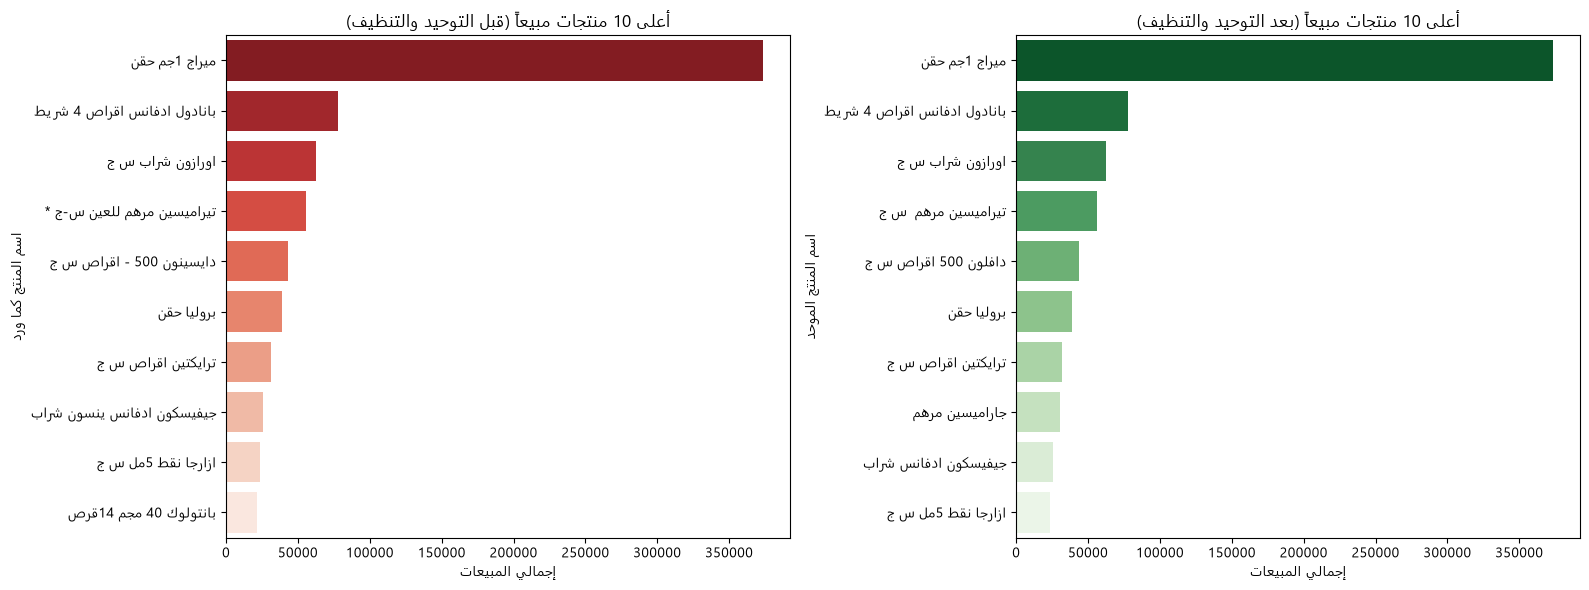

In [11]:
# ج. رسم بياني يوضح تأثير التنظيف على أعلى المنتجات مبيعاً
top_products_before = df.groupby('product_name')['total_amount'].sum().sort_values(ascending=False).head(10)
top_products_after = df.groupby('clean_product_name')['total_amount'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=top_products_before.values, y=top_products_before.index, ax=axes[0], palette='Reds_r')
axes[0].set_title('أعلى 10 منتجات مبيعاً (قبل التوحيد والتنظيف)')
axes[0].set_xlabel('إجمالي المبيعات')
axes[0].set_ylabel('اسم المنتج كما ورد')

sns.barplot(x=top_products_after.values, y=top_products_after.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('أعلى 10 منتجات مبيعاً (بعد التوحيد والتنظيف)')
axes[1].set_xlabel('إجمالي المبيعات')
axes[1].set_ylabel('اسم المنتج الموحد')

plt.tight_layout()
plt.savefig('cleaning_impact_comparison.png', dpi=100)
plt.show()

## المرحلة 5: التعلم الآلي والتنبؤ (Machine Learning)

في هذا الجزء سنقوم بتطبيق 3 نماذج تعلم آلي:
1. **اكتشاف العمليات الشاذة (Anomaly Detection):** باستخدام خوارزمية **Isolation Forest** لتحديد الصفقات الشاذة أو المشكوك فيها (مثل خصم غير منطقي أو كمية ضخمة جداً).
2. **التنبؤ بالمبيعات (Sales Forecasting):** تجميع المبيعات يومياً وإنشاء خصائص زمنية وتدريب نموذج للتنبؤ بالمبيعات للأيام القادمة.
3. **التنبؤ بالطلب (Demand Prediction):** التنبؤ بحجم الطلب (الكميات المباعة) على أكثر منتج مبيعاً لدينا.

In [12]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

print("--- 1. اكتشاف العمليات الشاذة (Anomaly Detection) ---")

# اختيار الخصائص الرقمية للتحليل
features = ['quantity', 'discount', 'total_amount']
X = df[features].copy()

# تقييس البيانات
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# تدريب نموذج Isolation Forest
# نسبة التلوث المتوقعة 1% (أي 1% من البيانات قد تكون شاذة)
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df['is_anomaly'] = iso_forest.fit_predict(X_scaled)
# تحويل التصنيف: 1 لطبيعي، -1 لشاذ
df['is_anomaly'] = df['is_anomaly'].map({1: 0, -1: 1})

anomalies = df[df['is_anomaly'] == 1]
print(f"تم اكتشاف {len(anomalies)} عملية شاذة من إجمالي {len(df)} صف.")

# عرض بعض العمليات الشاذة المكتشفة
print("\nأمثلة على العمليات الشاذة المكتشفة:")
print(anomalies[['clean_account_name', 'clean_product_name', 'quantity', 'discount', 'total_amount']].head(10).to_string(index=False))

# حفظ المعاملات الشاذة في ملف منفصل للتنبيهات
anomalies.to_csv('detected_anomalies.csv', index=False)


--- 1. اكتشاف العمليات الشاذة (Anomaly Detection) ---
تم اكتشاف 100 عملية شاذة من إجمالي 10000 صف.

أمثلة على العمليات الشاذة المكتشفة:
              clean_account_name                  clean_product_name  quantity  discount  total_amount
ص مها مديرية امن الجيزة &ش*& 003                 تيراميسين مرهم  س ج        30       4.0        806.40
ص مها مديرية امن الجيزة &ش*& 003                 تيراميسين مرهم  س ج        50       7.0       1302.00
ص مها مديرية امن الجيزة &ش*& 003                 تيراميسين مرهم  س ج        50      17.0       1162.00
ص مها مديرية امن الجيزة &ش*& 003                 تيراميسين مرهم  س ج        50      21.0       1106.00
 ص محمد مكاوى كرداسة اى سبلاى 05     يونيكتام 750مج  1فيال س ج/المهن        64      31.0       1722.24
    ص/ياسر فتحى فيصل توصيل م س +           اريك 100مج 12ق  س ق/ادويا        15      67.0        712.80
    ص/ياسر فتحى فيصل توصيل م س + دافا ليندى حقن (بديل ديفارول)/المهن        25      13.0       1218.00
    ص/ياسر فتحى فيصل توصيل م س +      في

--- 2. التنبؤ بالمبيعات المستقبلية (Sales Forecasting) ---


متوسط الخطأ المطلق للتنبؤ (MAE) على مدار 30 يوماً الأخيرة: 8326.07 جنيه


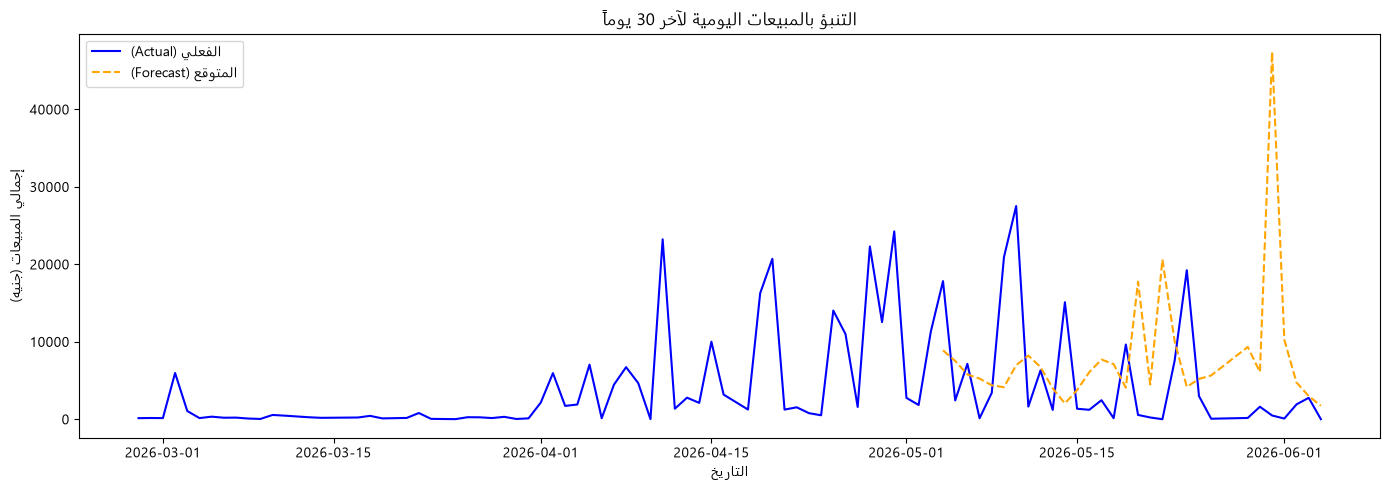

In [13]:
from sklearn.ensemble import RandomForestRegressor
from datetime import timedelta

print("--- 2. التنبؤ بالمبيعات المستقبلية (Sales Forecasting) ---")

# تحويل تاريخ الفاتورة مع معالجة التواريخ التالفة "0000-00-00" باستخدام errors='coerce'
df['date'] = pd.to_datetime(df['creation_date'], errors='coerce').dt.date

# حذف التواريخ التالفة (التي تحولت إلى NaT)
df_clean_dates = df.dropna(subset=['date']).copy()

daily_sales = df_clean_dates.groupby('date')['total_amount'].sum().reset_index()
daily_sales['date'] = pd.to_datetime(daily_sales['date'])
daily_sales = daily_sales.sort_values('date').reset_index(drop=True)

# إنشاء خصائص زمنية للتنبؤ (Time Features)
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek
daily_sales['day_of_month'] = daily_sales['date'].dt.day
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['lag_1'] = daily_sales['total_amount'].shift(1)
daily_sales['lag_7'] = daily_sales['total_amount'].shift(7)
daily_sales['rolling_mean_7'] = daily_sales['total_amount'].shift(1).rolling(window=7).mean()

# حذف الصفوف التي تحتوي على قيم مفقودة نتيجة الـ Shift
daily_sales_clean = daily_sales.dropna().copy()

# تقسيم البيانات إلى تدريب واختبار (آخر 30 يوم للاختبار)
train_data = daily_sales_clean.iloc[:-30]
test_data = daily_sales_clean.iloc[-30:]

feature_cols = ['day_of_week', 'day_of_month', 'month', 'lag_1', 'lag_7', 'rolling_mean_7']
X_train, y_train = train_data[feature_cols], train_data['total_amount']
X_test, y_test = test_data[feature_cols], test_data['total_amount']

# تدريب نموذج RandomForest
model_forecaster = RandomForestRegressor(n_estimators=100, random_state=42)
model_forecaster.fit(X_train, y_train)

# التنبؤ على بيانات الاختبار
test_data = test_data.copy()
test_data['predicted_sales'] = model_forecaster.predict(X_test)

# حساب متوسط الخطأ المطلق
mae = np.mean(np.abs(test_data['predicted_sales'] - y_test))
print(f"متوسط الخطأ المطلق للتنبؤ (MAE) على مدار 30 يوماً الأخيرة: {mae:.2f} جنيه")

# رسم بياني للتنبؤ مقابل الفعلي
plt.figure(figsize=(14, 5))
plt.plot(daily_sales_clean['date'].iloc[-90:], daily_sales_clean['total_amount'].iloc[-90:], label='الفعلي (Actual)', color='blue')
plt.plot(test_data['date'], test_data['predicted_sales'], label='المتوقع (Forecast)', color='orange', linestyle='--')
plt.title('التنبؤ بالمبيعات اليومية لآخر 30 يوماً')
plt.xlabel('التاريخ')
plt.ylabel('إجمالي المبيعات (جنيه)')
plt.legend()
plt.tight_layout()
plt.savefig('sales_forecast_plot.png', dpi=100)
plt.show()


In [14]:
print("--- 3. التنبؤ بحجم الطلب على المنتجات (Demand Prediction) ---")

# اختيار المنتج الأكثر مبيعاً (ميراج 1جم حقن) وتجميع الكميات المباعة منه يومياً
top_prod_name = "ميراج 1جم حقن"
top_prod_df = df[df['clean_product_name'] == top_prod_name].copy()
top_prod_df['date'] = pd.to_datetime(top_prod_df['creation_date'], errors='coerce').dt.date

# حذف التواريخ التالفة
top_prod_df = top_prod_df.dropna(subset=['date']).copy()

daily_demand = top_prod_df.groupby('date')['quantity'].sum().reset_index()
daily_demand['date'] = pd.to_datetime(daily_demand['date'])
daily_demand = daily_demand.sort_values('date').reset_index(drop=True)

# إعادة تعبئة الأيام الفارغة (إذا لم يكن هناك مبيعات في يوم ما)
all_dates = pd.date_range(start=daily_demand['date'].min(), end=daily_demand['date'].max())
daily_demand = daily_demand.set_index('date').reindex(all_dates, fill_value=0).reset_index()
daily_demand.columns = ['date', 'quantity']

# إنشاء خصائص زمنية
daily_demand['day_of_week'] = daily_demand['date'].dt.dayofweek
daily_demand['month'] = daily_demand['date'].dt.month
daily_demand['lag_1'] = daily_demand['quantity'].shift(1)
daily_demand['lag_7'] = daily_demand['quantity'].shift(7)
daily_demand_clean = daily_demand.dropna().copy()

# تدريب النموذج
X_demand = daily_demand_clean[['day_of_week', 'month', 'lag_1', 'lag_7']]
y_demand = daily_demand_clean['quantity']

demand_model = RandomForestRegressor(n_estimators=100, random_state=42)
demand_model.fit(X_demand, y_demand)
print(f"تم تدريب نموذج التنبؤ بالطلب لمنتج '{top_prod_name}' بنجاح.")


--- 3. التنبؤ بحجم الطلب على المنتجات (Demand Prediction) ---
تم تدريب نموذج التنبؤ بالطلب لمنتج 'ميراج 1جم حقن' بنجاح.
